# Introduction

This notebook demonstrates the use of any UCoMP data products displayed with an AIA image in the same map using SunPy. This notebook is intended to serve as a comprehensive example for all of the available UCoMP data products; a more in-depth example using only level 2 data product and creating an AIA composite image can be found in ucomp-wcs.ipynb. 

#### Credits

Thanks to Yingjie Zhu for the initial notebook for this display and pointing out problems in our initial UCoMP level 1 headers.

#### Requirements

- The **astropy, sunpy, aiapy, matplotlib, skimage, mlso-api, and mlso-instruments** libraries are required to run this notebook. You can install the mlso-api library with the following command: `pip install mlso-api`, and the mlso-instruments library with the following command: `pip install mlso-instruments`

- In order to to download data files via the mlso-api, the user **must** register their email with the following HAO website:  https://registration.hao.ucar.edu
  
- Network access is required so FIDO can download the AIA image taken close in time to the UCoMP image.

In [1]:
# imports
from astropy.io import fits
import astropy.units as u
from astropy.visualization import ImageNormalize, AsinhStretch, PowerStretch
from astropy.coordinates import SkyCoord
import numpy as np 
import sunpy
from sunpy.map import Map
import matplotlib.pyplot as plt
from sunpy.coordinates import SphericalScreen
import matplotlib.pyplot as plt
from pathlib import Path
import copy
import os 
from astropy.time import Time
from sunpy.net import Fido, attrs as a
import datetime
from datetime import timedelta, datetime
from aiapy.calibrate import register, update_pointing
from aiapy.calibrate.utils import get_pointing_table
from skimage import exposure 

# Install via: pip install mlso-api-client, pip install mlso-intruments
from mlso.api import client 
from mlso.instruments import ucomp 

# Data Level Descriptions

A complete and in-depth description of UCoMP data can be found in the document "UCoMP Data User’s Guide" on the MLSO website, at https://mlso.hao.ucar.edu/files/UCoMP-Data-User's-Guide-for-Distrubtion_Web_2023nov29.pdf  

Each data product type (for Level 1 and Level 2 data) is shown in its own section in this notebook, along with instructions on how to customize your search. A simplified description of the different data products is given in the table below: 

| Data Product Type      |   Title             |     Description                                        |
| --- | --- | ---  |   
| mean                   |   Level 1 Mean      |     Mean of level 1 files                              |   
| median                 |   Level 1 Median    |     Median of level 1 files                            |
| sigma                  |   Level 1 Sigma     |     Standard deviation of level 1 files                |
| l2                     |   Level 2           |     Level 2 products                                   |
| l2average              |   Level 2 Average   |     Mean, median, standard deviation of level 2 files  |
| density                |   Leve 3 Density    |     Electron density                                   |      

<div class="alert alert-block alert-info">
<b>Note:</b> To access data via the mlso-api, the user is required to register their email (which will become the parameter username) with the following HAO website -  https://registration.hao.ucar.edu
</div>


**Update the username with your registered email in the cell below.**

In [ ]:
username = "username@example.com" 

# Level 1 Mean

Level 1 mean files are averaged level 1 data products created by combining individual files, and thus are available for an entire day as opposed to indivualized timestamps. 

Level 1 mean files have the filename structure of yyyymmdd.ucomp.wavelength.l1.program.mean.fts, where: 
- yyyymmdd is the date of observation
- wavelength is the integer wavelength in nm
- program is the observing program name (ex: "waves" or "synoptic" are available most days, but different programs may appear for other campaigns) 

In the code cell below, four variables can be modified to customize your search: 
1. **start_date**: the starting date and time in UTC of the time interval of UCoMP data to examine
2. **time_interval_minutes**: the time interval in minutes past the start_date to search for files from. Note that because these files are created once daily, you may need to expand the time interval significantly to find a day's file
3. **wavelength**: the wavelength in nm from the following list, in order of brightest to least bright [1074, 1079, 789, 637, 706]
4. **program**: if wavelength is set to 1074, can be set to either "waves" or "synoptic", otherwise "synoptic" 

In [3]:
# change the following to customize the notebook
start_date = "2022-04-13T17:00:00" 
time_interval_minutes = 240
wavelength = 1074
program = "synoptic"

Search for the nearest file in your time interval:

In [4]:
# calculate the time interval to search for files from 
import datetime
time_interval = datetime.timedelta(minutes=time_interval_minutes)
datetime_fmt = "%Y-%m-%dT%H:%M:%S"
end_date = (datetime.datetime.strptime(start_date, datetime_fmt) + time_interval).strftime(datetime_fmt)
print(f"looking for UCoMP files between {start_date}..{end_date}")

# find closest file 
ucomp_files = client.files("ucomp", "mean", filters={"start-date": start_date, "end-date": end_date, "wave-region": wavelength, "obs-plan": program}) 
if len(ucomp_files["files"]) < 1: 
    print(f"found 0 files in the time interval. please change start_date or time_interval_minutes")
else: 
    ucomp_filename = ucomp_files["files"][0]["filename"]
    if os.path.exists(ucomp_filename):
        print(f"found {ucomp_filename}, using cached file...")
    else:
        print(f"found {ucomp_filename}, downloading...")
        client.authenticate(username)
        _ = client.download_file(ucomp_files["files"][0], ".") 

looking for UCoMP files between 2022-04-13T17:00:00..2022-04-13T21:00:00
found 20220413.ucomp.1074.l1.synoptic.mean.fts, using cached file...


Plot the Stokes IQUV for the observing wavelengths available in your selected file (default is three, but may include more):

Filename: 20220413.ucomp.1074.l1.synoptic.mean.fts
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     197   ()      
  1  Corona Stokes IQUV [1074.59 nm]    1 ImageHDU        31   (1280, 1024, 4)   float32   
  2  Corona Stokes IQUV [1074.70 nm]    1 ImageHDU        31   (1280, 1024, 4)   float32   
  3  Corona Stokes IQUV [1074.81 nm]    1 ImageHDU        31   (1280, 1024, 4)   float32   
  4  Background I [1074.59 nm]    1 ImageHDU        27   (1280, 1024)   float32   
  5  Background I [1074.70 nm]    1 ImageHDU        27   (1280, 1024)   float32   
  6  Background I [1074.81 nm]    1 ImageHDU        27   (1280, 1024)   float32   
There are 3 wavelengths in this level 1 file.


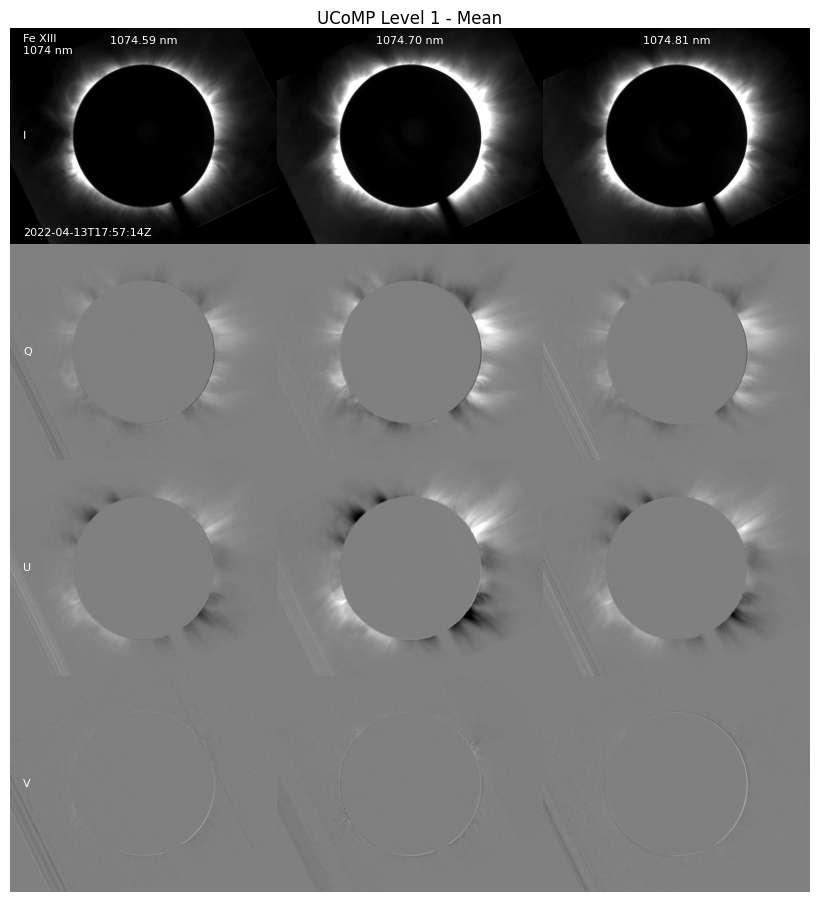

In [7]:
iquv_data, bkg_data, wvs, ucomp_time = ucomp.l1_data(ucomp_filename)

ucomp.l1_mosiac_image(iquv_data, ucomp_time, wvs, wavelength, 'Mean')

# Level 1 Median 

Level 1 medium files are the median of level 1 data products created by combining individual files, and thus are available for an entire day as opposed to indivualized timestamps. 

Level 1 median files have the filename structure of yyyymmdd.ucomp.wavelength.l1.program.median.fts, where: 
- yyyymmdd is the date of observation
- wavelength is the integer wavelength in nm
- program is the observing program name (ex: "waves" or "synoptic" are available most days, but different programs may appear for other campaigns) 

In the code cell below, four variables can be modified to customize your search: 
1. **start_date**: the starting date and time in UTC of the time interval of UCoMP data to examine
2. **time_interval_minutes**: the time interval in minutes past the start_date to search for files from. Note that because these files are created once daily, you may need to expand the time interval significantly to find a day's file
3. **wavelength**: the wavelength in nm from the following list, in order of brightest to least bright [1074, 1079, 789, 637, 706]
4. **program**: if wavelength is set to 1074, can be set to either "waves" or "synoptic"

In [8]:
# change the following to customize the notebook
start_date = "2022-04-13T17:00:00" 
time_interval_minutes = 240
wavelength = 1074
program = "synoptic"

Search for the nearest file in your time interval:

In [ ]:
# calculate the time interval to search for files from 
import datetime
time_interval = datetime.timedelta(minutes=time_interval_minutes)
datetime_fmt = "%Y-%m-%dT%H:%M:%S"
end_date = (datetime.datetime.strptime(start_date, datetime_fmt) + time_interval).strftime(datetime_fmt)
print(f"looking for UCoMP files between {start_date}..{end_date}")

# find closest file 
ucomp_files = client.files("ucomp", "median", filters={"start-date": start_date, "end-date": end_date, "wave-region": wavelength, "obs-plan": program}) 
if len(ucomp_files["files"]) < 1: 
    print(f"found 0 files in the time interval. please change start_date or time_interval_minutes")
else: 
    ucomp_filename = ucomp_files["files"][0]["filename"]
    if os.path.exists(ucomp_filename):
        print(f"found {ucomp_filename}, using cached file...")
    else:
        print(f"found {ucomp_filename}, downloading...")
        client.authenticate(username)
        _ = client.download_file(ucomp_files["files"][0], ".")

looking for UCoMP files between 2022-04-13T17:00:00..2022-04-13T21:00:00
found 20220413.ucomp.1074.l1.synoptic.median.fts, using cached file...


Plot the Stokes IQUV for the observing wavelengths available in your selected file (default is three, but may include more):

Filename: 20220413.ucomp.1074.l1.synoptic.median.fts
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     197   ()      
  1  Corona Stokes IQUV [1074.59 nm]    1 ImageHDU        31   (1280, 1024, 4)   float32   
  2  Corona Stokes IQUV [1074.70 nm]    1 ImageHDU        31   (1280, 1024, 4)   float32   
  3  Corona Stokes IQUV [1074.81 nm]    1 ImageHDU        31   (1280, 1024, 4)   float32   
  4  Background I [1074.59 nm]    1 ImageHDU        27   (1280, 1024)   float32   
  5  Background I [1074.70 nm]    1 ImageHDU        27   (1280, 1024)   float32   
  6  Background I [1074.81 nm]    1 ImageHDU        27   (1280, 1024)   float32   
There are 3 wavelengths in this level 1 file.


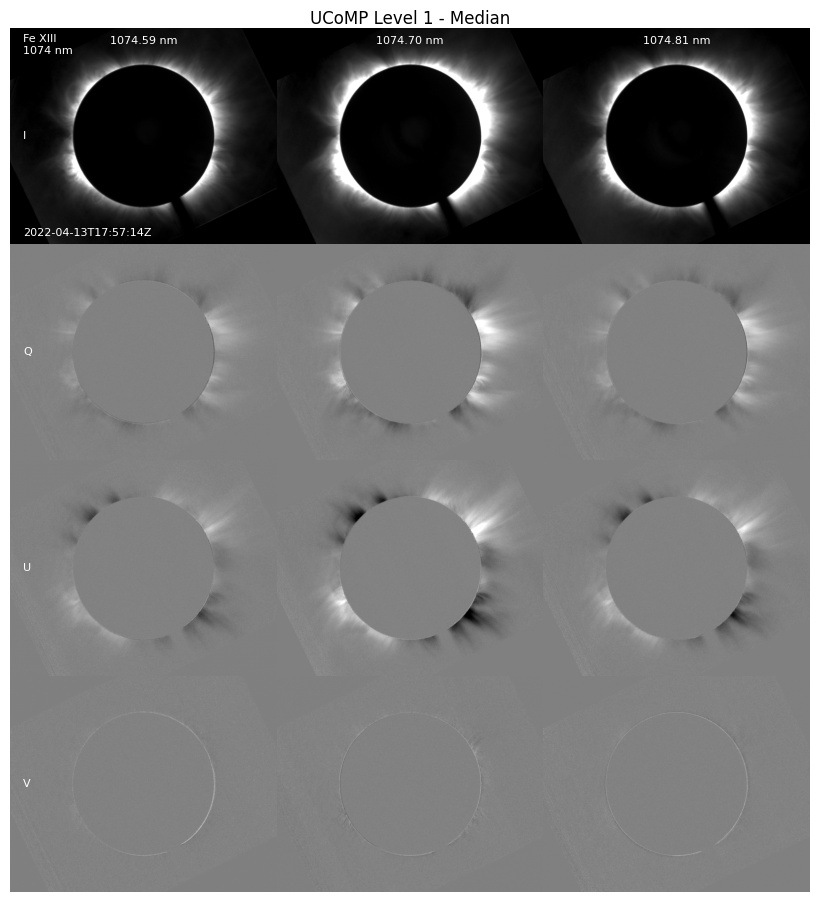

In [11]:
iquv_data, bkg_data, wvs, ucomp_time = ucomp.l1_data(ucomp_filename)

ucomp.l1_mosiac_image(iquv_data, ucomp_time, wvs, wavelength, 'Median')

# Level 1 Sigma 

Level 1 sigma files are the standard deviation of level 1 data products created by combining individual files, and thus are available for an entire day as opposed to indivualized timestamps. 

Level 1 median files have the filename structure of yyyymmdd.ucomp.wavelength.l1.program.median.fts, where: (???)
- yyyymmdd is the date of observation
- wavelength is the integer wavelength in nm
- program is the observing program name, which currently can either be "waves" or "synoptic" (but may expand in the future) for the 1074 wavelength, but only "synoptic" for other wavelengths

In the code cell below, four variables can be modified to customize your search: 
1. **start_date**: the starting date and time in UTC of the time interval of UCoMP data to examine
2. **time_interval_minutes**: the time interval in minutes past the start_date to search for files from. Note that because these files are created once daily, you may need to expand the time interval significantly to find a day's file
3. **wavelength**: the wavelength in nm from the following list, in order of brightest to least bright [1074, 1079, 789, 637, 706]
4. **program**: if wavelength is set to 1074, can be set to either "waves" or "synoptic"

# Level 2 

Level 2 data files contain intensity-derived polarization products and are generated from individual level 1 observations. Only level 1 files passing quality control (GBU) criteria are processed into level 2 files. Level 2 files are available for specific timestamps. 

Level 2 files have the filename structure of yyyymmdd.hhmmss.ucomp.wavelength.l2.fts when derived from a single level 1 file, where: 
- yyyymmdd is the date of observation
- hhmmss is time hour, minute, and second of observation
- wavelength is the integer wavelength in nm

Level 2 files contain the following data products: 
| Level 2 data product (data_product_type) |     Description                                        |
| -------------------- |  ----------------------------------------------------- |
| Center wavelength intensity | L1 intensity at center tuning wavelength | 
| Enhanced intensity | unsharp mask of center wavelength intensity | 
| Peak intensity | peak value of Gaussian analytical fit | 
| LOS velocity | line-of-sight (LOS) Doppler velocity derived from the Gaussian fit | 
| Line width | FWHM line width from Gaussian fit | 
| Noise mask | masks FOV pixels that failed to meet all signal thresholds; **not intended to be plotted on its own** | 
| Weighted average I | the sum of I at the center 3 wavelengths, divided by 2 | 
| Weighted average Q | the sum of Q at the center 3 wavelengths, divided by 2 | 
| Weighted average U | the sum of U at the center 3 wavelengths, divided by 2 | 
| Weighted average L | linear polarization from U and Q | 
| Azimuth | the azimuth angle from the ratio of U and Q | 
| Radial Azimuth | the azimuth angle with respect to the radial direction | 


<div class="alert alert-block alert-info">
<b>Note:</b> only wavelength 1074 and 1079 have the full list of data products included in the table above. Other wavelengths only have center wavelength intensity through noise mask as available parameters.
</div>


In the code cell below, four variables can be modified to customize your search: 
1. **start_date**: the starting date and time in UTC of the time interval of UCoMP data to examine
2. **time_interval_minutes**: the time interval in minutes past the start_date to search for files from. Note that because these files are created once daily, you may need to expand the time interval significantly to find a day's file
3. **wavelength**: the wavelength in nm from the following list, in order of brightest to least bright [1074, 1079, 789, 637, 706]
4. **data_product_type**: type of UCoMP data product used in analysis (***default is Enhanced Intensity***)

In [3]:
# change the following to customize the notebook
start_date = "2025-03-24T19:39:16" 
time_interval_minutes = 60
wavelength = 1074
data_product_type = "Enhanced intensity" # note that this is case sensitive, and should follow the first column in the table above 

In [4]:
# calculate the time interval to search for files from 
import datetime
time_interval = datetime.timedelta(minutes=time_interval_minutes)
datetime_fmt = "%Y-%m-%dT%H:%M:%S"
end_date = (datetime.datetime.strptime(start_date, datetime_fmt) + time_interval).strftime(datetime_fmt)
print(f"looking for UCoMP files between {start_date}..{end_date}")

# find closest file 
ucomp_files = client.files("ucomp", "l2", filters={"start-date": start_date, "end-date": end_date, "wave-region": wavelength})
if len(ucomp_files["files"]) < 1: 
    print(f"found 0 files in the time interval. please change start_date or time_interval_minutes")
else: 
    ucomp_filename = ucomp_files["files"][0]["filename"]
    if os.path.exists(ucomp_filename):
        print(f"found {ucomp_filename}, using cached file...")
    else:
        print(f"found {ucomp_filename}, downloading...")
        client.authenticate(username)
        _ = client.download_file(ucomp_files["files"][0], ".") 

looking for UCoMP files between 2025-03-24T19:39:16..2025-03-24T20:39:16
found 20250324.193916.ucomp.1074.l2.fts, using cached file...


Plot the chosen Level 2 data product: 

Filename: 20250324.193916.ucomp.1074.l2.fts
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     208   ()      
  1  Center wavelength intensity    1 ImageHDU        19   (1280, 1024)   float32   
  2  Enhanced intensity    1 ImageHDU        19   (1280, 1024)   float32   
  3  Peak intensity    1 ImageHDU        26   (1280, 1024)   float32   
  4  LOS velocity    1 ImageHDU        29   (1280, 1024)   float32   
  5  Line width (FWHM)    1 ImageHDU        21   (1280, 1024)   float32   
  6  Noise mask    1 ImageHDU        18   (1280, 1024)   float32   
  7  Weighted average I    1 ImageHDU        18   (1280, 1024)   float32   
  8  Weighted average Q    1 ImageHDU        18   (1280, 1024)   float32   
  9  Weighted average U    1 ImageHDU        18   (1280, 1024)   float32   
 10  Weighted average L    1 ImageHDU        18   (1280, 1024)   float32   
 11  Azimuth       1 ImageHDU        18   (1280, 1024)   float32   
 12  Radial azimuth    1 

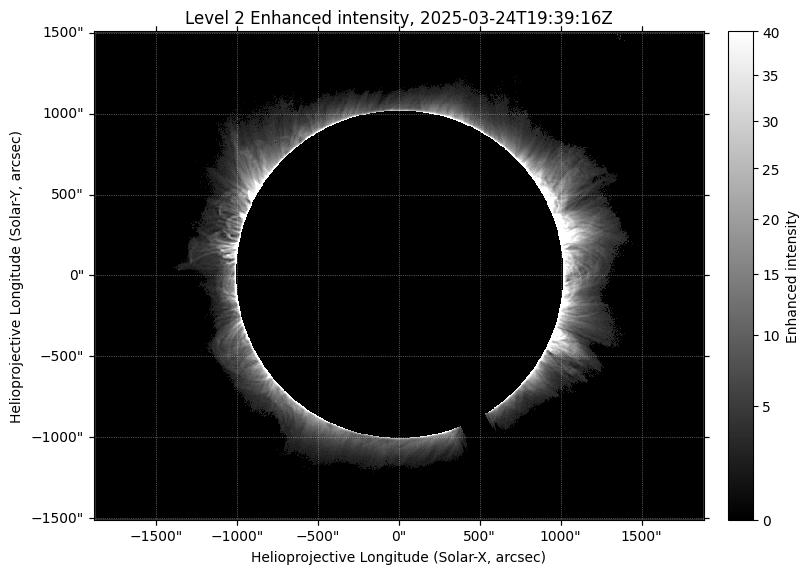

In [5]:
ucomp_time, ucomp_map = ucomp.l2_map(ucomp_filename, wavelength, data_product_type)

fig = plt.figure(figsize=(8, 8), constrained_layout=True)
[vmin, vmax, gamma, power], rgb = ucomp.l2_normalization_parameters(wavelength, data_product_type)
norm_ucomp = ImageNormalize(ucomp_map.data, stretch=PowerStretch(power), vmin=vmin, vmax=vmax)
ax = fig.add_subplot(projection=ucomp_map)
im = ucomp_map.plot(axes=ax, norm=norm_ucomp, cmap='ucomp_current')
ax.set_facecolor("black")
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label=data_product_type)
ax.set_xlabel('Helioprojective Longitude (Solar-X, arcsec)')
ax.set_ylabel('Helioprojective Longitude (Solar-Y, arcsec)')
ax.coords[0].set_ticks(number=8)
ax.coords[1].set_ticks(number=8)
utc_string = ucomp_time.strftime("%Y-%m-%dT%H:%M:%SZ")
plt.title(f'Level 2 {data_product_type}, {utc_string}')
plt.show()

# Level 2 Average

Level 2 average data files contain the mean, median, and standard deviation of the intensity-derived polarization products in Level 2 files. These products are described in detail in the section above, Level 2. As with averaged products for Level 1 data, Level 2 average data files created by combining individual files, and thus are available for an entire day as opposed to indivualized timestamps.

Level 2 files have the filename structure of yyyymmdd.ucomp.wavelength.l2.program.grouping.fts, where: 
- yyyymmdd is the date of observation
- wavelength is the integer wavelength in nm
- program is the observing program name, which currently can either be "waves" or "synoptic" (but may expand in the future) for the 1074 wavelength, but only "synoptic" for other wavelengths
- grouping delinates if the file is a mean or median of that day's data

In the code cell below, three variables can be modified to customize your search: 
1. **start_date**: the starting date and time in UTC of the time interval of UCoMP data to examine
2. **time_interval_minutes**: the time interval in minutes past the start_date to search for files from. Note that because these files are created once daily, you may need to expand the time interval significantly to find a day's file
3. **wavelength**: the wavelength in nm from the following list, in order of brightest to least bright [1074, 1079, 789, 637, 706]
4. **program**: if wavelength is set to 1074, can be set to either "waves" or "synoptic"
5. **grouping**: type of averaging (mean or median)  

In [6]:
# change the following to customize the notebook
start_date = "2025-03-24T19:39:16" 
time_interval_minutes = 60
wavelength = 1074
program = "synoptic"
grouping = "mean"

In [7]:
# calculate the time interval to search for files from 
import datetime
time_interval = datetime.timedelta(minutes=time_interval_minutes)
datetime_fmt = "%Y-%m-%dT%H:%M:%S"
end_date = (datetime.datetime.strptime(start_date, datetime_fmt) + time_interval).strftime(datetime_fmt)
print(f"looking for UCoMP files between {start_date}..{end_date}")

# find closest file 
ucomp_files = client.files("ucomp", "l2average", filters={"start-date": start_date, "end-date": end_date, "wave-region": wavelength})
if len(ucomp_files["files"]) < 1: 
    print(f"found 0 files in the time interval. please change start_date or time_interval_minutes")
else: 
    ucomp_filename = ucomp_files["files"][0]["filename"]
    if os.path.exists(ucomp_filename):
        print(f"found {ucomp_filename}, using cached file...")
    else:
        print(f"found {ucomp_filename}, downloading...")
        client.authenticate(username)
        _ = client.download_file(ucomp_files["files"][0], ".") 

looking for UCoMP files between 2025-03-24T19:39:16..2025-03-24T20:39:16
found 0 files in the time interval. please change start_date or time_interval_minutes


Plot the chosen Level 2 data product: 

Filename: 20250324.193916.ucomp.1074.l2.fts
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     208   ()      
  1  Center wavelength intensity    1 ImageHDU        19   (1280, 1024)   float32   
  2  Enhanced intensity    1 ImageHDU        19   (1280, 1024)   float32   
  3  Peak intensity    1 ImageHDU        26   (1280, 1024)   float32   
  4  LOS velocity    1 ImageHDU        29   (1280, 1024)   float32   
  5  Line width (FWHM)    1 ImageHDU        21   (1280, 1024)   float32   
  6  Noise mask    1 ImageHDU        18   (1280, 1024)   float32   
  7  Weighted average I    1 ImageHDU        18   (1280, 1024)   float32   
  8  Weighted average Q    1 ImageHDU        18   (1280, 1024)   float32   
  9  Weighted average U    1 ImageHDU        18   (1280, 1024)   float32   
 10  Weighted average L    1 ImageHDU        18   (1280, 1024)   float32   
 11  Azimuth       1 ImageHDU        18   (1280, 1024)   float32   
 12  Radial azimuth    1 

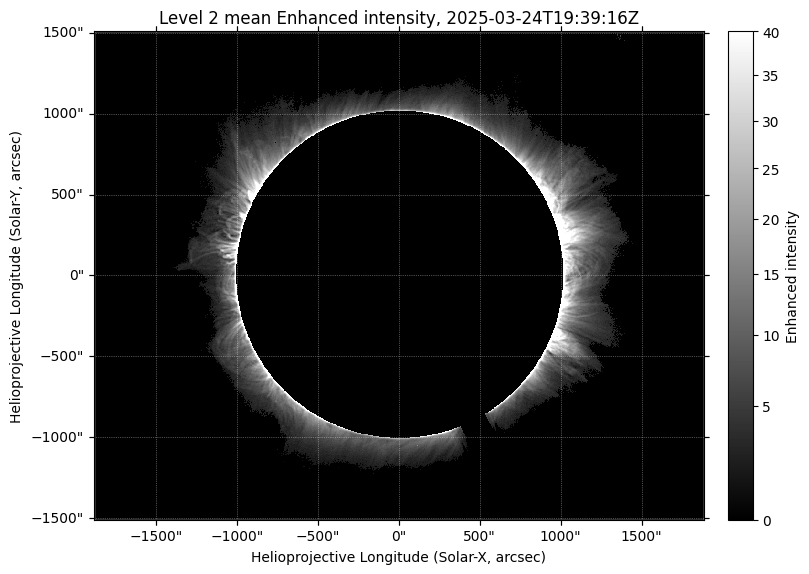

In [8]:
ucomp_time, ucomp_map = ucomp.l2_map(ucomp_filename, wavelength, data_product_type)

fig = plt.figure(figsize=(8, 8), constrained_layout=True)
[vmin, vmax, gamma, power], rgb = ucomp.l2_normalization_parameters(wavelength, data_product_type)
norm_ucomp = ImageNormalize(ucomp_map.data, stretch=PowerStretch(power), vmin=vmin, vmax=vmax)
ax = fig.add_subplot(projection=ucomp_map)
im = ucomp_map.plot(axes=ax, norm=norm_ucomp, cmap='ucomp_current')
ax.set_facecolor("black")
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label=data_product_type)
ax.set_xlabel('Helioprojective Longitude (Solar-X, arcsec)')
ax.set_ylabel('Helioprojective Longitude (Solar-Y, arcsec)')
ax.coords[0].set_ticks(number=8)
ax.coords[1].set_ticks(number=8)
utc_string = ucomp_time.strftime("%Y-%m-%dT%H:%M:%SZ")
plt.title(f'Level 2 {grouping} {data_product_type}, {utc_string}')
plt.show()

# Level 3 Density

Level 3 Electron Density data files are calculated from the line ratio of the Fe XIII 1074.7nm and 1079.8nm lines.

Level 2 files have the filename structure of yyyymmdd.hhmmss-hhmmss.ucomp.1074-1079.density.fts, where: 
- yyyymmdd is the date of observation
- hhmmss-hhmmss is the duration of the observation, spanning two times in hour, minute, and second 
- 1074-1079 represent the wavelengths 1074.7 and 1079.8 in nm 

In the code cell below, three variables can be modified to customize your search: 
1. **start_date**: the starting date and time in UTC of the time interval of UCoMP data to examine
2. **time_interval_minutes**: the time interval in minutes past the start_date to search for files from. Note that because these files are created once daily, you may need to expand the time interval significantly to find a day's file

In [9]:
# change the following to customize the notebook
start_date = "2025-03-24T18:00:00" 
time_interval_minutes = 120

In [10]:
# calculate the time interval to search for files from 
import datetime
time_interval = datetime.timedelta(minutes=time_interval_minutes)
datetime_fmt = "%Y-%m-%dT%H:%M:%S"
end_date = (datetime.datetime.strptime(start_date, datetime_fmt) + time_interval).strftime(datetime_fmt)
print(f"looking for UCoMP files between {start_date}..{end_date}")

# find closest file 
ucomp_files = client.files("ucomp", "density", filters={"start-date": start_date, "end-date": end_date})
if len(ucomp_files["files"]) < 1: 
    print(f"found 0 files in the time interval. please change start_date or time_interval_minutes")
else: 
    ucomp_filename = ucomp_files["files"][0]["filename"]
    if os.path.exists(ucomp_filename):
        print(f"found {ucomp_filename}, using cached file...")
    else:
        print(f"found {ucomp_filename}, downloading...")
        client.authenticate(username)
        _ = client.download_file(ucomp_files["files"][0], ".") 

looking for UCoMP files between 2025-03-24T18:00:00..2025-03-24T20:00:00
found 20250324.193916-193333.ucomp.1074-1079.density.fts, downloading...


Plot level 3 density:

Filename: 20250324.193916-193333.ucomp.1074-1079.density.fts
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   ()      
  1  Density       1 ImageHDU        35   (1280, 1024)   float32   
  2  Peak intensity [1074 nm]    1 ImageHDU        40   (1280, 1024)   float32   
  3  Peak intensity [1079 nm]    1 ImageHDU        40   (1280, 1024)   float32   


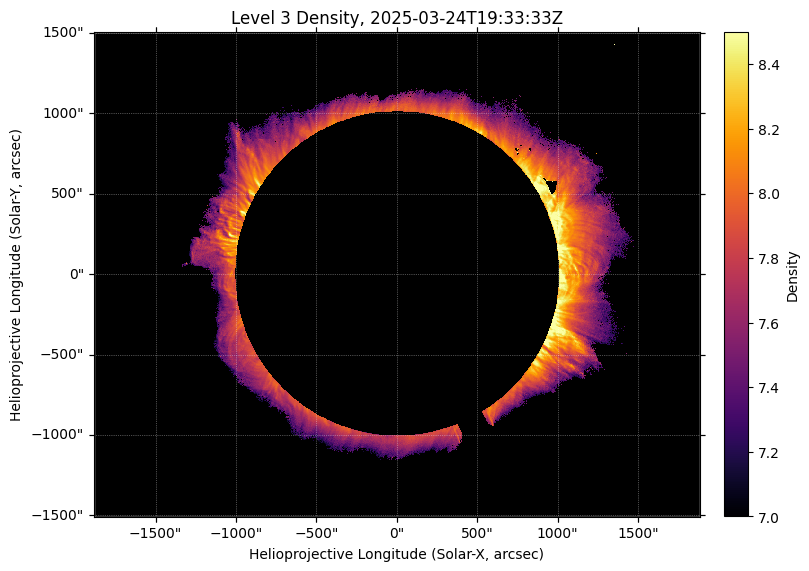

In [11]:
ucomp_time, ucomp_map = ucomp.l3_map(ucomp_filename)

fig = plt.figure(figsize=(8, 8), constrained_layout=True)
vmin, vmax, gamma, power = 7, 8.5, 1.0, 1.0
norm_ucomp = ImageNormalize(ucomp_map.data, stretch=PowerStretch(power), vmin=vmin, vmax=vmax)
ax = fig.add_subplot(projection=ucomp_map)
im = ucomp_map.plot(axes=ax, norm=norm_ucomp, cmap='inferno')
ax.set_facecolor("black")
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label='Density')
ax.set_xlabel('Helioprojective Longitude (Solar-X, arcsec)')
ax.set_ylabel('Helioprojective Longitude (Solar-Y, arcsec)')
ax.coords[0].set_ticks(number=8)
ax.coords[1].set_ticks(number=8)
utc_string = ucomp_time.strftime("%Y-%m-%dT%H:%M:%SZ")
plt.title(f'Level 3 Density, {utc_string}')
plt.show()